In [21]:
#Scaling features using StandardScaler
import pandas as pd
from sklearn.preprocessing import StandardScaler
import joblib

features = pd.read_csv("..//data/processed/movie_features.csv")
print("features.shape: ",features.shape)

X = features.drop(columns=['movieId'])
#scaled to remove biasness of large values in the dataset. 
scaler = StandardScaler() 
X_scaled = scaler.fit_transform(X) 
joblib.dump(scaler,"..//models/scaler.pkl") # Save the scaler for future use

features.shape:  (9724, 24)


['..//models/scaler.pkl']

In [22]:
# Analyzing the variance of the features using PCA. variance is the measure of how far a set 
# of numbers are spread out from their average value. PCA is used to reduce the dimensionality
# of the dataset while preserving as much variance as possible.
from sklearn.decomposition import PCA
pca = PCA()
pca.fit(X_scaled)
explained = pca.explained_variance_ratio_
import numpy as np
cum_var=np.cumsum(explained)
print("Cumulative variance: \n",cum_var)
print("Total variance explained: ", pca.explained_variance_ratio_.sum()) 

Cumulative variance: 
 [0.0962585  0.18549858 0.25178842 0.3104227  0.36539375 0.41799039
 0.46708999 0.51441108 0.55814541 0.60046928 0.6418858  0.68302698
 0.72109683 0.75868976 0.79382894 0.82670333 0.85901297 0.88922899
 0.91694527 0.94123366 0.96505834 0.98572978 1.        ]
Total variance explained:  0.9999999999999998


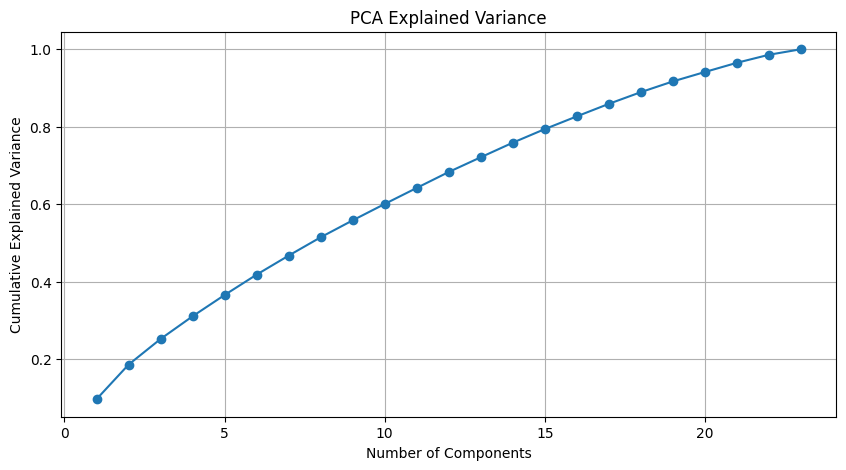

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(
    range(1,len(cum_var)+1),
    cum_var,
    marker='o'
)

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.grid(True)
plt.savefig('..//outputs/pca_variance.png',dpi=300,bbox_inches='tight')
plt.show()
#plot shows that 95% of the variance is explained by the first 20 components. Therefore, we can reduce the dimensionality of the dataset to 20 components while retaining most of the information.

In [24]:
# Reducing the dimensionality of the dataset using PCA. 
# The number of components is set to 0.95, which means that the PCA will retain 95% of 
# the variance in the dataset.
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)
joblib.dump(pca, "..//models/pca.pkl")
print(X.shape)
print(X_pca.shape)
print("Total variance explained: ", pca.explained_variance_ratio_.sum()) 

(9724, 23)
(9724, 21)
Total variance explained:  0.9650583375232655


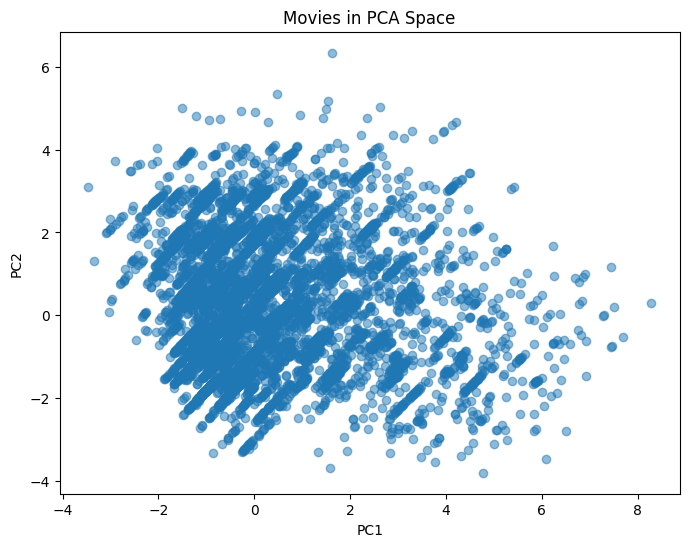

In [25]:
pca_vis = PCA(n_components=2)
X_vis = pca_vis.fit_transform(X_scaled)
vis_df = pd.DataFrame(X_vis,columns=['PC1','PC2'])
plt.figure(figsize=(8,6))
plt.scatter(vis_df['PC1'],vis_df['PC2'],alpha=0.5)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Movies in PCA Space")
plt.savefig("..//outputs/pca_movies.png",dpi=300,bbox_inches='tight')
plt.show()

In [26]:
pca_df = pd.DataFrame(X_pca)
print(pca_df.head())
pca_df['movieId'] = features['movieId']
pca_df.to_csv(
    "..//outputs/pca_features.csv",
    index=False
)

         0         1         2         3         4         5         6   \
0  6.923529 -0.622405  3.653590  1.650460 -1.074854  1.560218 -0.134682   
1  4.497216 -0.043198  2.216751  0.859241 -0.089031  0.363486  0.425357   
2 -0.090674 -1.454600 -0.192217 -0.157205 -1.862521  0.130831 -0.317642   
3 -0.912260 -1.702799 -0.356695 -0.120277 -1.836550 -0.063194  0.801612   
4  0.190519 -0.716639 -0.589899 -0.174251 -0.881254  0.279559 -0.878279   

         7         8         9   ...        11        12        13        14  \
0  3.449177  0.439344  0.699551  ... -4.109098  0.514095 -0.255219 -2.794391   
1  1.278206  0.336701  0.372130  ... -2.206418  0.896990  1.690563 -2.313469   
2  1.969479  0.298862 -0.075284  ... -0.726550  0.379521  0.086895  0.210605   
3  0.227479  0.090094 -0.170911  ...  0.326244  0.012137  0.239836  0.542260   
4  0.975727  0.084691 -0.091573  ... -0.807363  0.356678 -0.479864 -0.481378   

         15        16        17        18        19        20  
0  3